# import libraries

In [54]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,mean_absolute_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# load data

In [27]:
diabetes = load_diabetes()
X= diabetes.data
y= diabetes.target
X_train,X_test,y_train,y_test= train_test_split( X,y, test_size= 0.2 ,random_state=42)

In [51]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

# GridSearchCV

In [29]:
models_params= [
("Linear Regression", LinearRegression(), {}),
("Ridge", Ridge(), {'model__alpha': [0.1 ,1.0 ,10.0]}),
("Lasso", Lasso(), {'model__alpha': [0.01, 0.1, 1.0]}),
("ElasticNet", ElasticNet(), {'model__alpha': [ 0.1, 1.0] , 'model__l1_ratio':[0.2,0.5]}),
("K-Neighbors", KNeighborsRegressor(), {'model__n_neighbors':[3,5,11]}),
("SVR", SVR(), {'model__C': [1,10], 'model__gamma': ['scale','auto']}),
("Decision Tree", DecisionTreeRegressor(), {'model__max_depth': [None,5,10]}),
("Random Forest", RandomForestRegressor(random_state=42), {'model__n_estimators':[50,100]}),
("Gradient Boosting", GradientBoostingRegressor(random_state=42), {'model__learning_rate':[0.01,0.1]}),
("AdaBoost", AdaBoostRegressor(random_state=42), {'model__n_estimators':[50,100]}),
]

In [44]:
results= []
for name ,model ,params in models_params:
    pipeline= Pipeline([
        ('scaler', StandardScaler()),
        ('model',model)
    ])
    grid= GridSearchCV(pipeline, params, cv=5,scoring='r2',n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model= grid.best_estimator_
    y_pred= best_model.predict(X_test)
    results.append({
    'Model':name,
    'Best Params': grid.best_params_,
    'Test R2': r2_score(y_test,y_pred),
    'Test MAE': mean_absolute_error(y_test,y_pred)
     })


In [45]:
df_results= pd.DataFrame(results).sort_values(by='Test R2',ascending=False)
print(df_results[['Model', 'Test R2', 'Test MAE']])

               Model   Test R2   Test MAE
5                SVR  0.493713  41.319671
2              Lasso  0.466877  42.802984
3         ElasticNet  0.459798  42.930479
1              Ridge  0.457211  42.856825
8  Gradient Boosting  0.452979  44.593020
0  Linear Regression  0.452603  42.794095
7      Random Forest  0.441469  44.171236
9           AdaBoost  0.434057  45.127275
4        K-Neighbors  0.415137  45.589377
6      Decision Tree  0.305086  47.569914


# prediction

In [50]:
new_patient_data= np.array([[0.05,-0.04,0.08,0.02,-0.01,-0.02,-0.03,0.04,0.05,0.011111]])
prediction= best_model.predict(new_patient_data)
print(f'پیش بینی مدل برای شدت بیماری دیابت: {prediction[0]:.2f}')

پیش بینی مدل برای شدت بیماری دیابت: 237.58


# chart

In [55]:
y_pred= best_model.predict(X_test)
errors= y_test - y_pred

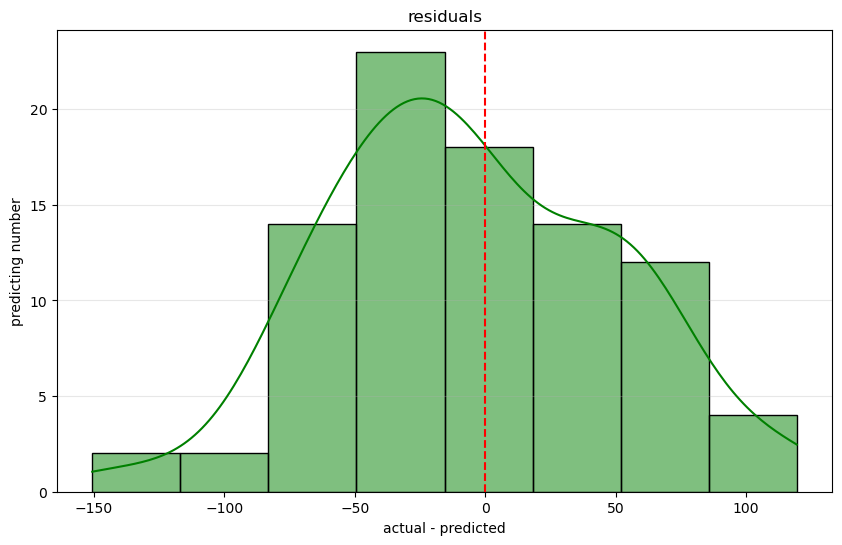

In [56]:
plt.figure(figsize=(10,6))
sns.histplot(errors,kde=True,color='green')
plt.axvline(x=0, color='red',linestyle='--')
plt.title('residuals')
plt.xlabel('actual - predicted')
plt.ylabel('predicting number')
plt.grid(axis='y' , alpha=0.3)
plt.show()